# 05 — Model-Class Sensitivity & Robustness  [R1-7, R1-9]
Equivalence without UNITSTOTAL, ablation, and LightGBM vs Logistic Regression (as-delivered / scaled / nested-tuned).

In [1]:
import json, inspect, warnings, os, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (StandardScaler, RobustScaler, PowerTransformer, MinMaxScaler, QuantileTransformer)
from sklearn.metrics import (accuracy_score, matthews_corrcoef, roc_auc_score, recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from scipy import stats
from lightgbm import LGBMClassifier
os.makedirs("results", exist_ok=True)
RS = 42
TEAL,ROSE,ORANGE,SAND,RED,LAV,SLATE,INK = ('#4A90A4','#C4887D','#E67E22','#C4A882','#C0392B','#8E7CC3','#7A8B9A','#2C3E4F')
plt.rcParams.update({'font.family':'DejaVu Sans','axes.facecolor':'#FAFBFC','figure.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.color':'#E4E9F0',
    'axes.titleweight':'bold','axes.axisbelow':True,'savefig.dpi':200,'savefig.bbox':'tight'})
NAMES = ['Manual Expert','DeepSeek','Claude Sonnet 4.6','GPT-5.4','CAAFE']
SHORT = ['Manual','DeepSeek','Claude 4.6','GPT-5.4','CAAFE']
COLS  = [TEAL,ROSE,RED,ORANGE,LAV]
CONT  = ['AGE','ANNUALCONTRIBUTION','ANNUALCLAIMAMOUNT','UNITSTOTAL']
DATA  = "Final Prepared Dataset - Diabetes and Hypertension Data.xlsx"

def load_raw():
    df = pd.read_excel(DATA)
    n_raw = len(df); df = df.drop_duplicates().reset_index(drop=True); n_dup = n_raw - len(df)
    df["ADHERENCE"] = (df["ADHERENCE"]=="ADHERENT").astype(int)
    for c in df.columns:
        if df[c].dtype=="bool": df[c]=df[c].astype(int)
    return df, n_raw, n_dup

def load_and_split():
    df,_,_ = load_raw()
    y=df["ADHERENCE"]; X=df.drop(columns=["ADHERENCE"])
    return train_test_split(X,y,test_size=0.2,stratify=y,random_state=RS)

def _manual(Xp):
    Xp=Xp.copy()
    Xp["LOG_CLAIM"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]); Xp["LOG_UNITS"]=np.log1p(Xp["UNITSTOTAL"])
    Xp["LOG_CONTRIB"]=np.log1p(Xp["ANNUALCONTRIBUTION"])
    Xp["CLAIM_PER_UNIT"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["UNITSTOTAL"]+1))
    Xp["CLAIM_RATIO"]=np.log1p(Xp["ANNUALCLAIMAMOUNT"]/(Xp["ANNUALCONTRIBUTION"]+1))
    Xp["UNITS_PER_AGE"]=Xp["UNITSTOTAL"]/(Xp["AGE"]+1); return Xp

_NS={"np":np,"pd":pd,"StandardScaler":StandardScaler,"RobustScaler":RobustScaler,
     "PowerTransformer":PowerTransformer,"MinMaxScaler":MinMaxScaler,"QuantileTransformer":QuantileTransformer}
def _load(p):
    ns=dict(_NS); exec(open(p,encoding="utf-8").read(),ns); return ns["preprocess"]
FROZEN={"DeepSeek":_load("llm_raw/DeepSeek_preprocess.py"),
        "Claude Sonnet 4.6":_load("llm_raw/Claude_Sonnet_4.6_preprocess.py"),
        "GPT-5.4":_load("llm_raw/GPT-5.4_preprocess.py")}
def _caafe(frame):
    ns={"df":frame.copy(),"np":np,"pd":pd}; exec(open("llm_raw/CAAFE_code.py",encoding="utf-8").read(),ns)
    return ns["df"].select_dtypes(include=[np.number]).fillna(0)
def transform_pair(name,x_fit,x_eval):
    if name=="Manual Expert": return _manual(x_fit),_manual(x_eval)
    if name=="CAAFE":
        tr=_caafe(x_fit); te=_caafe(x_eval).reindex(columns=tr.columns,fill_value=0); return tr,te
    tr,te=FROZEN[name](x_fit.copy(),x_eval.copy())
    if not isinstance(tr,pd.DataFrame):
        cols=(list(x_fit.columns)+["CONTRIBUTION_CLAIM_RATIO","UNITS_PER_CLAIM"]) if (name=="DeepSeek" and tr.shape[1]==x_fit.shape[1]+2) else [f"f{i}" for i in range(tr.shape[1])]
        tr=pd.DataFrame(tr,index=x_fit.index,columns=cols)
    if not isinstance(te,pd.DataFrame): te=pd.DataFrame(te,index=x_eval.index,columns=tr.columns)
    return tr,te.reindex(columns=tr.columns,fill_value=0)
def san(df): return pd.DataFrame(df).replace([np.inf,-np.inf],np.nan).fillna(0.0)
def nb_se(d,k=10):
    d=np.asarray(d); n=d.size; return np.sqrt(d.var(ddof=1)*(1.0/n+(1.0/k)/(1-1.0/k)))
def tost90(d,k=10):
    d=np.asarray(d); m=d.mean(); se=nb_se(d,k); c=stats.t.ppf(0.95,d.size-1); return m,se,[m-c*se,m+c*se]
def cv_metrics(name,X,y,drop_units=False,k=10,repeats=1):
    accs,mccs,aucs=[],[],[]
    for r in range(repeats):
        for tr,va in StratifiedKFold(k,shuffle=True,random_state=(RS if repeats==1 else 2026+r)).split(X,y):
            ftr,fva=transform_pair(name,X.iloc[tr],X.iloc[va])
            if drop_units:
                uc=[c for c in ftr.columns if 'UNIT' in c.upper()]
                ftr=ftr.drop(columns=uc); fva=fva.drop(columns=[c for c in uc if c in fva.columns])
            ftr,fva=san(ftr),san(fva)
            m=LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1).fit(ftr,y.iloc[tr])
            p=m.predict(fva); pr=m.predict_proba(fva)[:,1]
            accs.append(accuracy_score(y.iloc[va],p)); mccs.append(matthews_corrcoef(y.iloc[va],p)); aucs.append(roc_auc_score(y.iloc[va],pr))
    return np.array(accs),np.array(mccs),np.array(aucs)
x_tr,x_ho,y_tr,y_ho = load_and_split()
print("Setup complete |", f"{len(x_tr)+len(x_ho):,} records, {x_tr.shape[1]} predictors")

Setup complete | 24,071 records, 11 predictors


### [R1-9] Equivalence holds without UNITSTOTAL

,Pipeline,All features,UNITSTOTAL removed
0,Manual,0.8213,0.7558
1,DeepSeek,0.8229,0.7556
2,Claude 4.6,0.8214,0.7556
3,GPT-5.4,0.8215,0.7551
4,CAAFE,0.8204,0.7569


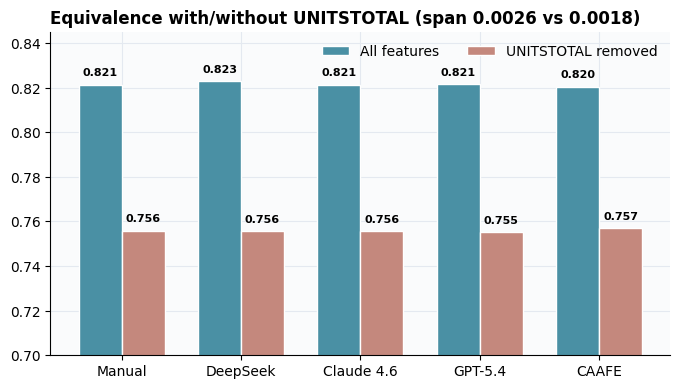

In [2]:
foldf={n:cv_metrics(n,x_tr,y_tr,repeats=5) for n in NAMES}
foldnu={n:cv_metrics(n,x_tr,y_tr,drop_units=True,repeats=5) for n in NAMES}
full=[foldf[n][0].mean() for n in NAMES]; nou=[foldnu[n][0].mean() for n in NAMES]; x=np.arange(5)
tbl=pd.DataFrame({'Pipeline':SHORT,'All features':np.round(full,4),'UNITSTOTAL removed':np.round(nou,4)})
display(tbl); tbl.to_excel('results/05_no_unitstotal.xlsx',index=False)
fig,ax=plt.subplots(figsize=(8,4.2)); bw=.36
ax.bar(x-bw/2,full,bw,color=TEAL,label='All features',edgecolor='white')
ax.bar(x+bw/2,nou,bw,color=ROSE,label='UNITSTOTAL removed',edgecolor='white')
for i,(a,b) in enumerate(zip(full,nou)):
    ax.text(i-bw/2,a+.004,f'{a:.3f}',ha='center',fontsize=8,fontweight='bold'); ax.text(i+bw/2,b+.004,f'{b:.3f}',ha='center',fontsize=8,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(SHORT); ax.set_ylim(.70,.845); ax.legend(ncol=2,frameon=False)
ax.set_title(f'Equivalence with/without UNITSTOTAL (span {max(full)-min(full):.4f} vs {max(nou)-min(nou):.4f})',loc='left')
plt.savefig('results/05_no_unitstotal.png'); plt.show()

### Ablation — ratio features drive the small gain

,Variant,Accuracy,Delta
0,Raw,0.8201,0.0000
1,+log1p,0.8201,0.0000
2,+ratios,0.8218,0.0018
3,log1p+ratio,0.8218,0.0018
4,+RobustScaler,0.8193,-0.0007


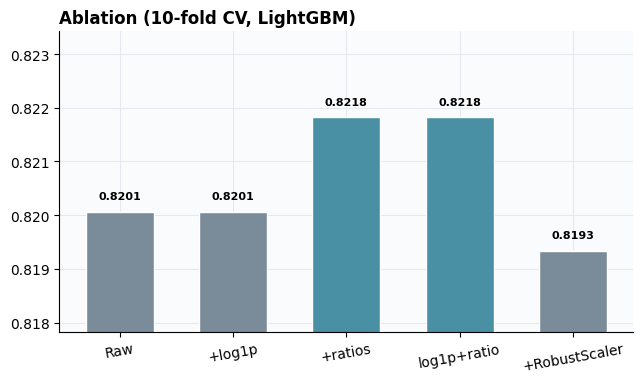

In [3]:
def enga(X,log=False,ratio=False,scale=False):
    Xp=X.copy()
    if log:
        for c in ['ANNUALCLAIMAMOUNT','UNITSTOTAL','ANNUALCONTRIBUTION']: Xp['LOG_'+c]=np.log1p(Xp[c])
    if ratio:
        Xp['CLAIM_PER_UNIT']=np.log1p(Xp['ANNUALCLAIMAMOUNT']/(Xp['UNITSTOTAL']+1))
        Xp['CLAIM_RATIO']=np.log1p(Xp['ANNUALCLAIMAMOUNT']/(Xp['ANNUALCONTRIBUTION']+1)); Xp['UNITS_PER_AGE']=Xp['UNITSTOTAL']/(Xp['AGE']+1)
    if scale: cols=Xp.select_dtypes(include=[np.number]).columns; Xp[cols]=RobustScaler().fit_transform(Xp[cols])
    return Xp
variants=[('Raw',{}),('+log1p',{'log':True}),('+ratios',{'ratio':True}),('log1p+ratio',{'log':True,'ratio':True}),('+RobustScaler',{'scale':True})]
cv=StratifiedKFold(10,shuffle=True,random_state=RS); accs=[cross_val_score(LGBMClassifier(random_state=RS,verbose=-1,n_jobs=1),san(enga(x_tr,**kw)),y_tr,cv=cv,scoring='accuracy').mean() for _,kw in variants]
abl=pd.DataFrame({'Variant':[v for v,_ in variants],'Accuracy':np.round(accs,4),'Delta':np.round(np.array(accs)-accs[0],4)})
display(abl); abl.to_excel('results/05_ablation.xlsx',index=False)
fig,ax=plt.subplots(figsize=(7.4,3.9)); ax.bar(range(5),accs,.6,color=[SLATE,SLATE,TEAL,TEAL,SLATE],edgecolor='white')
for i,a in enumerate(accs): ax.text(i,a+.0002,f'{a:.4f}',ha='center',va='bottom',fontsize=8,fontweight='bold')
ax.set_xticks(range(5)); ax.set_xticklabels([v for v,_ in variants],rotation=10); ax.set_ylim(min(accs)-.0015,max(accs)+.0016)
ax.set_title('Ablation (10-fold CV, LightGBM)',loc='left'); plt.savefig('results/05_ablation.png'); plt.show()

### [R1-7] LightGBM vs Logistic Regression (fair configurations)

,Pipeline,LightGBM,LR as-delivered,LR scaled+tuned
0,Manual,0.8213,0.7716,0.7886
1,DeepSeek,0.8229,0.7841,0.7843
2,Claude 4.6,0.8214,0.7864,0.7883
3,GPT-5.4,0.8215,0.7885,0.7884
4,CAAFE,0.8204,0.5863,0.6279


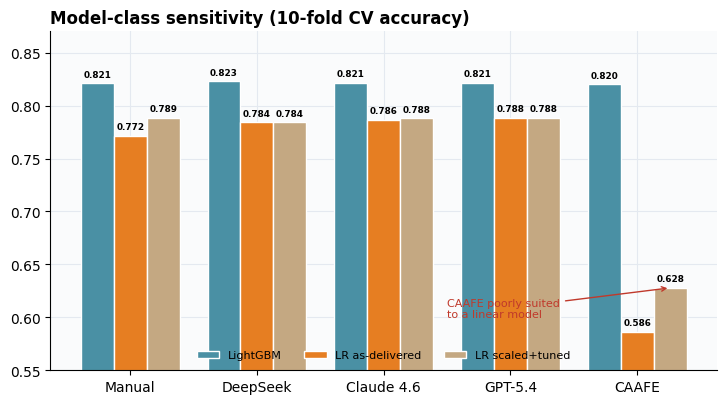

LightGBM span 0.0026 | LR raw 0.202 | LR tuned 0.161


In [4]:
def lr_cv(name,mode):
    cv=StratifiedKFold(10,shuffle=True,random_state=RS); a=[]
    for tr,va in cv.split(x_tr,y_tr):
        ftr,fva=transform_pair(name,x_tr.iloc[tr],x_tr.iloc[va]); ftr,fva=san(ftr),san(fva)
        if mode!='raw':
            sc=StandardScaler(); ftr=pd.DataFrame(sc.fit_transform(ftr),columns=ftr.columns); fva=pd.DataFrame(sc.transform(fva),columns=ftr.columns)
        if mode=='tuned':
            gs=GridSearchCV(LogisticRegression(max_iter=5000,random_state=RS),{'C':[0.01,0.1,1,10,100]},cv=5,n_jobs=1); gs.fit(ftr,y_tr.iloc[tr]); m=gs.best_estimator_
        else: m=LogisticRegression(max_iter=5000,random_state=RS).fit(ftr,y_tr.iloc[tr])
        a.append(accuracy_score(y_tr.iloc[va],m.predict(fva)))
    return np.mean(a)
lg=[foldf[n][0].mean() for n in NAMES]; raw=[lr_cv(n,'raw') for n in NAMES]; tu=[lr_cv(n,'tuned') for n in NAMES]
ms=pd.DataFrame({'Pipeline':SHORT,'LightGBM':np.round(lg,4),'LR as-delivered':np.round(raw,4),'LR scaled+tuned':np.round(tu,4)})
display(ms); ms.to_excel('results/05_model_sensitivity.xlsx',index=False)
fig,ax=plt.subplots(figsize=(8.6,4.4)); bw=.26
ax.bar(x-bw,lg,bw,color=TEAL,label='LightGBM',edgecolor='white'); ax.bar(x,raw,bw,color=ORANGE,label='LR as-delivered',edgecolor='white'); ax.bar(x+bw,tu,bw,color=SAND,label='LR scaled+tuned',edgecolor='white')
for arr,o in ((lg,-bw),(raw,0),(tu,bw)):
    for i,v in enumerate(arr): ax.text(i+o,v+.006,f'{v:.3f}',ha='center',fontsize=6.4,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(SHORT); ax.set_ylim(.55,.87); ax.legend(ncol=3,frameon=False,fontsize=8,loc='lower center')
ax.annotate('CAAFE poorly suited\nto a linear model',xy=(4+bw,tu[4]),xytext=(2.5,.60),fontsize=8,color=RED,arrowprops=dict(arrowstyle='->',color=RED))
ax.set_title('Model-class sensitivity (10-fold CV accuracy)',loc='left'); plt.savefig('results/05_model_sensitivity.png'); plt.show()
print('LightGBM span %.4f | LR raw %.3f | LR tuned %.3f'%(max(lg)-min(lg),max(raw)-min(raw),max(tu)-min(tu)))